# Identifying Inefficient Telecom Operators

The task was assigned by a product manager from the product development department.

Service is developing a new feature that will provide managers with information about their least effective agents. Ineffective agents are those with a high number of missed incoming calls (internal and external), as well as high wait times for incoming calls. Such agents may also make a small number of outgoing calls if they are working on outbound calls.

It is necessary to define criteria for ineffectiveness, identify patterns, and test hypotheses.

Identifying ineffective employees will increase the value of the service to the client, thereby potentially increasing the customer's lifetime value. A motivation system for agents will also be developed in collaboration with HR.

### Contents

* [Step 1. Studying General Information. Data Preprocessing](#1-bullet)
* [Step 2. Exploratory Analysis](#2-bullet)
* 2.1. [Number of Agents at Client Sites](#2-1-bullet)
* 2.2. [Waiting Time for Incoming External Calls. Criteria for Identifying Ineffective Agents](#2-2-bullet)
* 2.3. [Share of Dropped Calls by Agent. Criteria for Identifying Ineffective Agents](#2-3-bullet)
* 2.4. [Number of Outgoing Calls. Criteria for Identifying Ineffective Agents](#2-4-bullet)
* [Step 3. Hypothesis Testing](#3-bullet)
* 3.1. [Testing the Hypothesis About Differences in Incoming Call Wait Times Depending on Tariff Plan](#3-1-bullet)
* 3.2. [Testing the Hypothesis About Differences in the Number of Missed Incoming Calls Depending on Tariff Plan](#3-2-bullet)
* 3.3. [Testing the Hypothesis About Differences in the Number of Outgoing Calls Depending on Tariff Plan](#3-3-bullet)
* [Step 4. Conclusions and Recommendations](#4-bullet)

### Step 1. Studying General Information. Data Preprocessing<a class="anchor" id="1-bullet"></a>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import math as mth
from scipy import stats as st

In [2]:
telecom_clients = pd.read_csv('https://code.s3.yandex.net/datasets/telecom_clients.csv')

In [3]:
telecom_dataset = pd.read_csv('https://code.s3.yandex.net/datasets/telecom_dataset.csv')

In [4]:
telecom_clients.head()

,user_id,tariff_plan,date_start
0,166713,A,2019-08-15
1,166901,A,2019-08-23
2,168527,A,2019-10-29
3,167097,A,2019-09-01
4,168193,A,2019-10-16


The telecom_clients.csv dataset contains the following columns:
* user_id — Client account ID in the service
* tariff_plan — Client's current tariff plan
* date_start — Client registration date in the service

Differences between tariff plans (A, B, C)
- Base price of tariff plan A - 5 000 conventional units (CU)
- Base price of tariff plan B - 2 000 conventional units (CU)
- Base price of tariff plan C - 1 000 conventional units (CU)
- Incoming calls are free on all tariffs

Domestic calls are free on all tariffs for up to 2,000 minutes per month, after which
the charges are:
* Tariff plan A - 0.1 conventional units per minute
* Tariff plan B - 0.15 conventional units per minute
* Tariff plan C - 0.3 conventional units per minute

Outgoing (non-internal) calls:
* Tariff plan A - 0.4 conventional units per minute
* Tariff plan B - 0.5 conventional units per minute
* Tariff plan C - 0.7 conventional units per minute

For each operator, the customer pays 100 conventional units on any tariff, in addition to
the base tariff and call rates.

In [5]:
telecom_clients.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 732 entries, 0 to 731
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   user_id      732 non-null    int64 
 1   tariff_plan  732 non-null    object
 2   date_start   732 non-null    object
dtypes: int64(1), object(2)
memory usage: 17.3+ KB


* The dataset contains 732 rows and three columns.
* There are no missing values.
* The "date_start" column needs to have its data type changed, converting the values ​​from string to date.

In [6]:
telecom_clients['date_start'] = pd.to_datetime(telecom_clients['date_start'], format='%Y-%m-%d')

In [7]:
telecom_clients.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 732 entries, 0 to 731
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   user_id      732 non-null    int64         
 1   tariff_plan  732 non-null    object        
 2   date_start   732 non-null    datetime64[ns]
dtypes: datetime64[ns](1), int64(1), object(1)
memory usage: 17.3+ KB


In [8]:
telecom_clients.duplicated().sum()

0


    
There are no duplicates in the telecom clients dataset.

In [9]:
telecom_dataset.head()

,user_id,date,direction,internal,operator_id,is_missed_call,calls_count,call_duration,total_call_duration
0,166377,2019-08-04 00:00:00+03:00,in,False,NaN,True,2,0,4
1,166377,2019-08-05 00:00:00+03:00,out,True,880022.0,True,3,0,5
2,166377,2019-08-05 00:00:00+03:00,out,True,880020.0,True,1,0,1
3,166377,2019-08-05 00:00:00+03:00,out,True,880020.0,False,1,10,18
4,166377,2019-08-05 00:00:00+03:00,out,False,880022.0,True,3,0,25


The telecom_dataset.csv dataset contains the following columns:
- user_id — Client Account ID in the Service
- date — Statistics Date
- direction — Call Direction (Out — Outgoing Call, In — Incoming Call)
- internal — Whether the Call is an Internal Call Between the Client's Operators
- operator_id — Operator ID
- is_missed_call — Whether the Call was Missed
- calls_count — Number of Calls
- call_duration — Call Duration (Excluding Wait Time)
- total_call_duration — Call Duration (Including Wait Time)

In [10]:
telecom_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53902 entries, 0 to 53901
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   user_id              53902 non-null  int64  
 1   date                 53902 non-null  object 
 2   direction            53902 non-null  object 
 3   internal             53785 non-null  object 
 4   operator_id          45730 non-null  float64
 5   is_missed_call       53902 non-null  bool   
 6   calls_count          53902 non-null  int64  
 7   call_duration        53902 non-null  int64  
 8   total_call_duration  53902 non-null  int64  
dtypes: bool(1), float64(1), int64(4), object(3)
memory usage: 3.3+ MB


* The dataset contains 53 902 rows and 9 columns.
* Missing values ​​in two columns: "internal" and "operator_id."
* The "date" column requires a data type change, converting the values ​​from string to date.

In [11]:
telecom_dataset['date'] = pd.to_datetime(telecom_dataset['date']).dt.tz_localize(None)

In [12]:
telecom_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53902 entries, 0 to 53901
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   user_id              53902 non-null  int64         
 1   date                 53902 non-null  datetime64[ns]
 2   direction            53902 non-null  object        
 3   internal             53785 non-null  object        
 4   operator_id          45730 non-null  float64       
 5   is_missed_call       53902 non-null  bool          
 6   calls_count          53902 non-null  int64         
 7   call_duration        53902 non-null  int64         
 8   total_call_duration  53902 non-null  int64         
dtypes: bool(1), datetime64[ns](1), float64(1), int64(4), object(2)
memory usage: 3.3+ MB


    The goal of the project is to identify ineffective operators.
    Operators were missing for 8 172 clients, representing 15.16% of the total number of clients.
    Since there is no logical way to replace missing values, the decision was made to remove the missing values.
    Despite the large amount of data involved,

In [13]:
telecom_dataset.dropna(subset = ['operator_id'], inplace = True)

In [14]:
telecom_dataset.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 45730 entries, 1 to 53900
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   user_id              45730 non-null  int64         
 1   date                 45730 non-null  datetime64[ns]
 2   direction            45730 non-null  object        
 3   internal             45670 non-null  object        
 4   operator_id          45730 non-null  float64       
 5   is_missed_call       45730 non-null  bool          
 6   calls_count          45730 non-null  int64         
 7   call_duration        45730 non-null  int64         
 8   total_call_duration  45730 non-null  int64         
dtypes: bool(1), datetime64[ns](1), float64(1), int64(4), object(2)
memory usage: 3.2+ MB


    There were 60 missing values ​​in the "internal" column, which is 0.13% of the data.

In [15]:
telecom_dataset.query('internal.isnull()').head()

,user_id,date,direction,internal,operator_id,is_missed_call,calls_count,call_duration,total_call_duration
1924,166406,2019-09-02,in,NaN,879898.0,False,1,2,9
6210,166541,2019-09-26,in,NaN,908960.0,False,1,393,423
6216,166541,2019-09-26,in,NaN,908958.0,False,2,547,612
7528,166604,2019-11-01,in,NaN,893402.0,False,1,94,117
8650,166658,2019-09-24,in,NaN,890404.0,False,1,150,157


* No relationship could be found for the "user_id" column - 30 unique users had missing values, and for 56.6% of users, this was a single call without the "internal/external" classification.
* No relationship could be found for the "date" column - 36 different dates contained a missing value. In 52.7% of cases, only one call without the "internal/external" classification was detected on this day.
* No relationship could be found for the "operator_id" column - 41 unique operators had calls without the "internal/external" classification. In 68.29% of cases, these operators had one call without the "internal/external" classification.

All calls with missing values ​​in the "internal" column are incoming. One of the criteria for identifying ineffective operators is the number of missed calls. Let's look at how many calls were answered and how many were missed.

In [16]:
telecom_dataset.query('internal.isnull()')['is_missed_call'].value_counts()

False    59
True      1
Name: is_missed_call, dtype: int64

    59 calls were answered and only 1 was missed. Since these missed calls cannot be logically recovered, and the percentage of missed calls is 0.13%, with only 1 missed call, the decision was made to remove them.

In [17]:
telecom_dataset.dropna(subset = ['internal'], inplace = True)

In [18]:
telecom_dataset.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 45670 entries, 1 to 53900
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   user_id              45670 non-null  int64         
 1   date                 45670 non-null  datetime64[ns]
 2   direction            45670 non-null  object        
 3   internal             45670 non-null  object        
 4   operator_id          45670 non-null  float64       
 5   is_missed_call       45670 non-null  bool          
 6   calls_count          45670 non-null  int64         
 7   call_duration        45670 non-null  int64         
 8   total_call_duration  45670 non-null  int64         
dtypes: bool(1), datetime64[ns](1), float64(1), int64(4), object(2)
memory usage: 3.2+ MB


    Let's check the dataset for duplicates.

In [19]:
telecom_dataset.duplicated().sum()

4179

    The dataset contains many duplicates (9.15% of the total number of rows). The ['date'] column was expected to contain dates and times. Since the time was always "00:00:00+03:00," it was difficult to determine whether these were truly duplicates or whether similar actions were performed on the same day but at different times.
    It was decided to remove the duplicates.

In [20]:
telecom_dataset.drop_duplicates().reset_index(drop = True)

,user_id,date,direction,internal,operator_id,is_missed_call,calls_count,call_duration,total_call_duration
0,166377,2019-08-05,out,True,880022.0,True,3,0,5
1,166377,2019-08-05,out,True,880020.0,True,1,0,1
2,166377,2019-08-05,out,True,880020.0,False,1,10,18
3,166377,2019-08-05,out,False,880022.0,True,3,0,25
4,166377,2019-08-05,out,False,880020.0,False,2,3,29
...,...,...,...,...,...,...,...,...,...
41486,168606,2019-11-09,out,False,957922.0,False,4,551,593
41487,168606,2019-11-10,out,True,957922.0,False,1,0,25
41488,168606,2019-11-10,out,True,957922.0,True,1,0,38
41489,168606,2019-11-11,out,True,957922.0,False,2,479,501


**Let's create a column ['waiting_time'] in which we will calculate the waiting time.**

In [21]:
telecom_dataset['waiting_time'] = telecom_dataset['total_call_duration'] - telecom_dataset['call_duration']


**Let's create a column ['avg_wait_time_per_call'] in which the average wait time will be calculated** 

In [22]:
telecom_dataset['avg_wait_time_per_call'] = telecom_dataset['waiting_time'] / telecom_dataset['calls_count']
telecom_dataset.head()

,user_id,date,direction,internal,operator_id,is_missed_call,calls_count,call_duration,total_call_duration,waiting_time,avg_wait_time_per_call
1,166377,2019-08-05,out,True,880022.0,True,3,0,5,5,1.666667
2,166377,2019-08-05,out,True,880020.0,True,1,0,1,1,1.000000
3,166377,2019-08-05,out,True,880020.0,False,1,10,18,8,8.000000
4,166377,2019-08-05,out,False,880022.0,True,3,0,25,25,8.333333
5,166377,2019-08-05,out,False,880020.0,False,2,3,29,26,13.000000


In [23]:
telecom_dataset[telecom_dataset['direction'] == "in"]['avg_wait_time_per_call'].describe()

count    13953.000000
mean        16.493897
std         13.531959
min          0.000000
25%          7.666667
50%         13.000000
75%         21.432432
max        261.000000
Name: avg_wait_time_per_call, dtype: float64

The average call wait time is 13 seconds.

25% of users waited no more than 7.6 seconds.

75% waited no more than 21.4 seconds.

The largest outlier in the data is 261 seconds (or 4.35 minutes).

The standard deviation is 13.5 seconds. Because the standard deviation is large, the dataset may contain significant anomalies or outliers.

  
**Convert categorical variables in two columns to numeric values: False = 0, True = 1**

In [24]:
telecom_dataset['internal'].value_counts()

False    39861
True      5809
Name: internal, dtype: int64

In [25]:
from sklearn.preprocessing import LabelEncoder
encoder =  LabelEncoder() # create a class variable LabelEncoder - encoder
telecom_dataset['internal'] = encoder.fit_transform(telecom_dataset['internal']) # We use an encoder to "translate" string names into numbers.
telecom_dataset['internal'].value_counts()

/opt/anaconda3/envs/practicum/lib/python3.9/site-packages/sklearn/utils/fixes.py:28: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import parse_version  # type: ignore


0    39861
1     5809
Name: internal, dtype: int64

In [26]:
telecom_dataset['is_missed_call'].value_counts()

False    30153
True     15517
Name: is_missed_call, dtype: int64

In [27]:
encoder =  LabelEncoder() # create a class variable LabelEncoder - encoder
telecom_dataset['is_missed_call'] = encoder.fit_transform(telecom_dataset['is_missed_call']) # We use an encoder to "translate" string names into numbers.
telecom_dataset['is_missed_call'].value_counts()

0    30153
1    15517
Name: is_missed_call, dtype: int64

### Step 2. Exploratory Analysis<a class="anchor" id="2-bullet"></a>

### 2.1. Number of Agents at Client Sites<a class="anchor" id="2-1-bullet"></a>

In [28]:
telecom_dataset['user_id'].nunique()

290

In [29]:
telecom_dataset['operator_id'].nunique()

1092

    The dataset contains 290 clients and 1092 operators.

In [30]:
telecom_dataset.groupby('user_id')['operator_id'].nunique().describe()

count    290.000000
mean       3.765517
std        5.717712
min        1.000000
25%        1.000000
50%        2.000000
75%        4.000000
max       50.000000
Name: operator_id, dtype: float64

On average, each client has 3.77 operators.

Looking at the median, each client has 2 operators.

The standard deviation is 5.71, indicating the presence of significant anomalies or outliers.

75% of clients have no more than 4 operators.

The maximum value is 50 operators.

Let's look at the boxplot.

<AxesSubplot:>

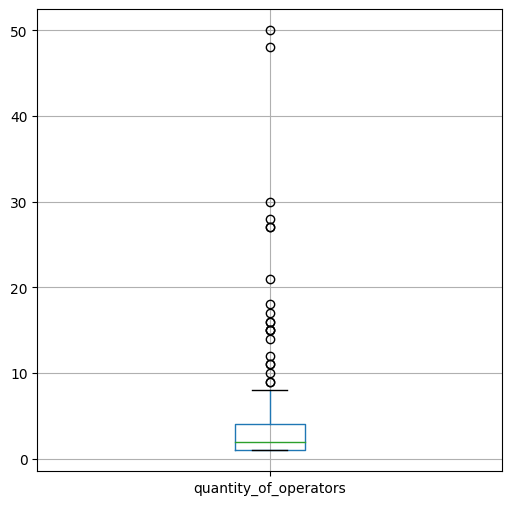

In [31]:
cnt_operators = telecom_dataset.groupby('user_id')['operator_id'].nunique().reset_index()
cnt_operators.columns = ['user_id','quantity_of_operators']
cnt_operators.boxplot(column='quantity_of_operators', figsize=(6,6))

(0.0, 9.0)

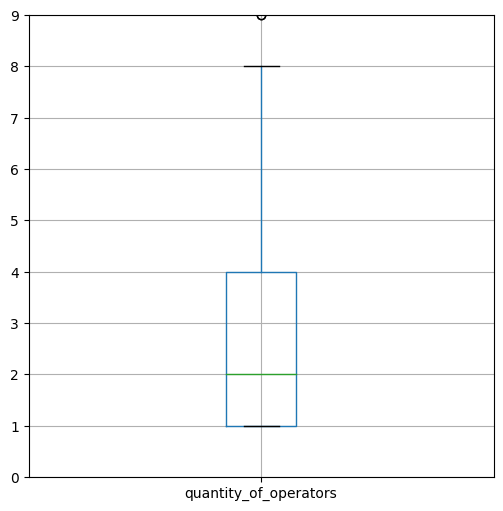

In [32]:
cnt_operators.boxplot(column='quantity_of_operators', figsize=(6,6))
plt.ylim(0,9)

Outliers start to appear after 8 operators per client.

Let's look at the data after removing outliers.

In [33]:
cnt_operators_cor = cnt_operators.query('quantity_of_operators <= quantity_of_operators.quantile(0.95)')
cnt_operators_cor['quantity_of_operators'].describe()

count    275.000000
mean       2.672727
std        2.103651
min        1.000000
25%        1.000000
50%        2.000000
75%        4.000000
max       12.000000
Name: quantity_of_operators, dtype: float64

/opt/anaconda3/envs/practicum/lib/python3.9/site-packages/seaborn/distributions.py:2557: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


Text(0.5, 1.0, 'Number of Operators per Clients')

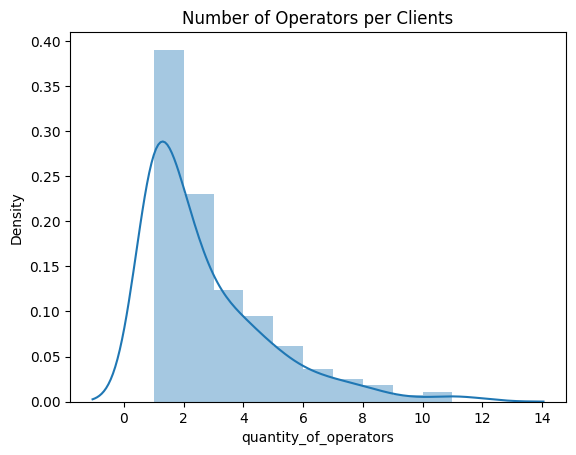

In [34]:
sns.distplot(cnt_operators_cor['quantity_of_operators'], norm_hist=True, bins = range(12), label='0')
plt.title('Number of Operators per Clients')

According to cleaned data:

Most clients have 1 to 2 operators.

50% of clients have no more than 2 operators.

75% of clients have no more than 4 operators.

The maximum number of operators in the sample without outliers is 12.

**Ratio of incoming and outgoing calls**

In [35]:
telecom_dataset['direction'].value_counts()

out    31717
in     13953
Name: direction, dtype: int64

The dataset contains 69.45% outgoing calls and 30.55% incoming calls.

**Can the operator handle both incoming and outgoing calls?**|

In [36]:
operator_in_2_groups = telecom_dataset.groupby('operator_id').agg({'direction':'nunique'})

operator_in_2_groups_filter = operator_in_2_groups[operator_in_2_groups['direction'] == 2].reset_index()
operator_in_2_groups_filter['operator_id'].nunique()

544

    544 of the 1,092 operators handle both outgoing and incoming calls.
    (49.82% of the total number of operators)

    Accordingly, 50.18% of operators handle only one group of calls.

### 2.2. Waiting Time for Incoming External Calls. Criteria for Identifying Ineffective Agents<a class="anchor" id="2-2-bullet"></a>

In [37]:
incoming_calls = telecom_dataset[telecom_dataset['direction'] == "in"]
incoming_calls.head()

,user_id,date,direction,internal,operator_id,is_missed_call,calls_count,call_duration,total_call_duration,waiting_time,avg_wait_time_per_call
26,166377,2019-08-12,in,0,880028.0,0,1,407,411,4,4.0
34,166377,2019-08-13,in,0,880028.0,0,1,88,102,14,14.0
37,166377,2019-08-14,in,0,880026.0,0,2,197,218,21,10.5
39,166377,2019-08-14,in,0,880028.0,0,1,33,37,4,4.0
49,166377,2019-08-15,in,0,880028.0,0,1,23,27,4,4.0


In [38]:
outer_incoming_calls = incoming_calls[incoming_calls['internal'] == 0]
outer_incoming_calls.head()

,user_id,date,direction,internal,operator_id,is_missed_call,calls_count,call_duration,total_call_duration,waiting_time,avg_wait_time_per_call
26,166377,2019-08-12,in,0,880028.0,0,1,407,411,4,4.0
34,166377,2019-08-13,in,0,880028.0,0,1,88,102,14,14.0
37,166377,2019-08-14,in,0,880026.0,0,2,197,218,21,10.5
39,166377,2019-08-14,in,0,880028.0,0,1,33,37,4,4.0
49,166377,2019-08-15,in,0,880028.0,0,1,23,27,4,4.0


In [39]:
outer_incoming_calls['avg_wait_time_per_call'].describe()

count    13535.000000
mean        16.577937
std         13.565961
min          0.000000
25%          7.732057
50%         13.000000
75%         21.500000
max        261.000000
Name: avg_wait_time_per_call, dtype: float64

The average wait time for an incoming external call was 16.58 seconds.

The standard deviation of 13.57 indicates outliers and anomalies in the sample.

25% of incoming external calls had a wait time of 7.73 seconds.

50% of incoming external calls had a wait time of 13 seconds.

75% of incoming external calls had a wait time of 21.5 seconds.

The maximum value was 261 seconds.

Let's look at the box plot.

<AxesSubplot:>

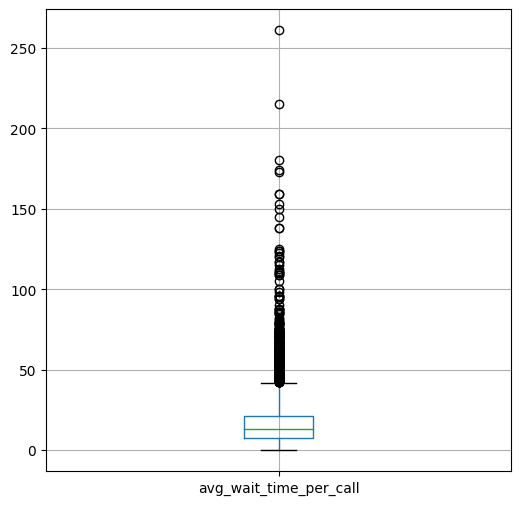

In [40]:
outer_incoming_calls.boxplot(column='avg_wait_time_per_call', figsize=(6,6))

(0.0, 43.0)

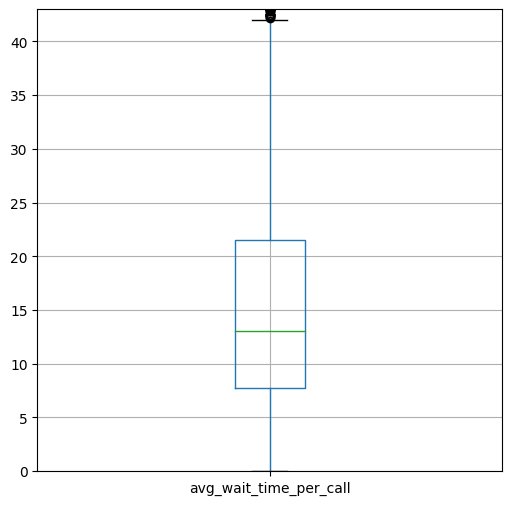

In [41]:
outer_incoming_calls.boxplot(column='avg_wait_time_per_call', figsize=(6,6))
plt.ylim(0, 43)

In [42]:
np.percentile(outer_incoming_calls['avg_wait_time_per_call'], [95])

array([40.5])

In [43]:
outer_incoming_calls = outer_incoming_calls.query('avg_wait_time_per_call <= avg_wait_time_per_call.quantile(0.95)')
outer_incoming_calls['avg_wait_time_per_call'].describe()

count    12867.000000
mean        14.509734
std          9.012814
min          0.000000
25%          7.500000
50%         12.333333
75%         20.000000
max         40.500000
Name: avg_wait_time_per_call, dtype: float64

/opt/anaconda3/envs/practicum/lib/python3.9/site-packages/seaborn/distributions.py:2557: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


Text(0.5, 1.0, 'Waiting Time for Incoming External Calls')

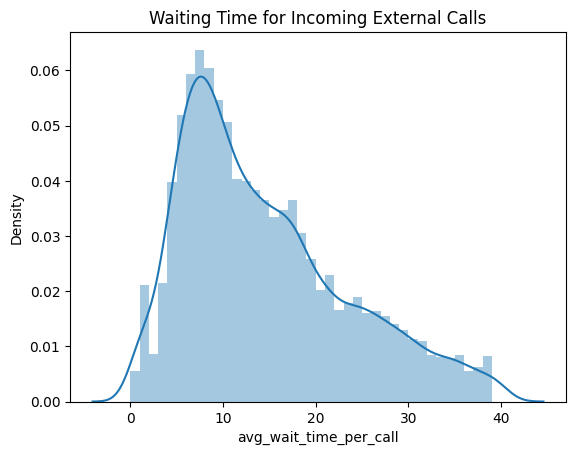

In [44]:
sns.distplot(outer_incoming_calls['avg_wait_time_per_call'],  norm_hist=True, bins = range(40))
plt.title('Waiting Time for Incoming External Calls')

In [45]:
np.percentile(outer_incoming_calls['avg_wait_time_per_call'], [55, 60])

array([13.75, 15.  ])

According to the cleaned data:

The average wait time for an incoming external call was 14.5 seconds.

25% of incoming external calls had a wait time of -7.5 seconds.

50% of incoming external calls had a wait time of -12.3 seconds.

75% of incoming external calls had a wait time of -20 seconds.

Outliers ranged from 40.5 to 261 seconds.

*We'll set a threshold of **15 seconds**, after which wait times will be considered high. Accordingly, agents answering incoming external calls for more than 15 seconds will be considered ineffective.*

In [46]:
check_incoming_calls = outer_incoming_calls.groupby('operator_id')['avg_wait_time_per_call'].mean().reset_index()
check_incoming_calls.head()

,operator_id,avg_wait_time_per_call
0,879896.0,11.378190
1,879898.0,10.385278
2,880020.0,7.250000
3,880022.0,14.000000
4,880026.0,5.991228



    
**A feature that identifies operators who answer calls for more than 15 seconds**

In [47]:
def check_avg_wait_time_per_call(avg_wait_time_per_call):
    if avg_wait_time_per_call > 15:
        return 'non-efficient'
    else:
        return 'accept'
 
check_incoming_calls['check'] = check_incoming_calls['avg_wait_time_per_call'].apply(check_avg_wait_time_per_call)

In [48]:
check_incoming_calls.head(10)

,operator_id,avg_wait_time_per_call,check
0,879896.0,11.378190,accept
1,879898.0,10.385278,accept
2,880020.0,7.250000,accept
3,880022.0,14.000000,accept
4,880026.0,5.991228,accept
5,880028.0,6.304444,accept
6,882476.0,15.500000,non-efficient
7,882478.0,13.000000,accept
8,882680.0,15.218699,non-efficient
9,882684.0,15.998179,non-efficient


### 2.3. Share of Dropped Calls by Agent. Criteria for Identifying Ineffective Agent.<a class="anchor" id="2-3-bullet"></a>

In [49]:
telecom_dataset['is_missed_call'].value_counts()

0    30153
1    15517
Name: is_missed_call, dtype: int64

    In the dataset, 66.02% of calls were accepted and 33.98% were not accepted.

In [50]:
telecom_dataset['date'].describe()

/var/folders/36/9gc9hhs127vfs3t2z0s015180000gn/T/ipykernel_70449/873507097.py:1: FutureWarning: Treating datetime data as categorical rather than numeric in `.describe` is deprecated and will be removed in a future version of pandas. Specify `datetime_is_numeric=True` to silence this warning and adopt the future behavior now.
  telecom_dataset['date'].describe()


count                   45670
unique                    118
top       2019-11-25 00:00:00
freq                     1083
first     2019-08-02 00:00:00
last      2019-11-28 00:00:00
Name: date, dtype: object

    The data is taken from 2019-08-02 to 2019-11-28 for 119 calendar days. Comparing the total number of missed calls by operator is inaccurate, as the operators worked different numbers of days. Therefore, for each operator, missed calls will be calculated for each day and the average number of missed calls per day will be calculated.

In [51]:
telecom_missed_call = telecom_dataset[telecom_dataset['is_missed_call'] == 1].reset_index()
telecom_missed_call.head()

,index,user_id,date,direction,internal,operator_id,is_missed_call,calls_count,call_duration,total_call_duration,waiting_time,avg_wait_time_per_call
0,1,166377,2019-08-05,out,1,880022.0,1,3,0,5,5,1.666667
1,2,166377,2019-08-05,out,1,880020.0,1,1,0,1,1,1.000000
2,4,166377,2019-08-05,out,0,880022.0,1,3,0,25,25,8.333333
3,6,166377,2019-08-05,out,0,880020.0,1,8,0,50,50,6.250000
4,8,166377,2019-08-05,out,0,880020.0,1,8,0,50,50,6.250000


In [52]:
cnt_missed_call = telecom_missed_call.groupby(['operator_id', 'date'])['calls_count'].mean().reset_index()
cnt_missed_call.head()

,operator_id,date,calls_count
0,879896.0,2019-08-02,8.0
1,879896.0,2019-08-03,7.0
2,879896.0,2019-08-04,1.0
3,879896.0,2019-08-05,1.0
4,879896.0,2019-08-06,4.0


In [53]:
cnt_missed_call['calls_count'].describe()

count    12321.000000
mean        20.053187
std         76.380174
min          1.000000
25%          2.000000
50%          5.000000
75%         16.000000
max       4817.000000
Name: calls_count, dtype: float64

The average number of missed calls per day for operators is 20.

The standard error of 76.38 indicates strong outliers and anomalies.

25% of operators miss up to 2 calls per day.

50% of operators missed fewer than 5 calls.

75% of operators missed fewer than 16 calls.

The maximum outlier is 4 817 missed calls. If an operator had a 12-hour workday, they would miss a call every 9 seconds, which is impossible.

Let's look at the box plot.

<AxesSubplot:>

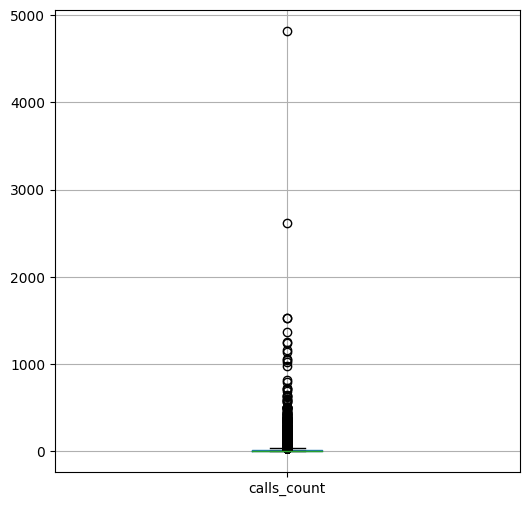

In [54]:
cnt_missed_call.boxplot(column='calls_count', figsize=(6,6))

(0.0, 37.5)

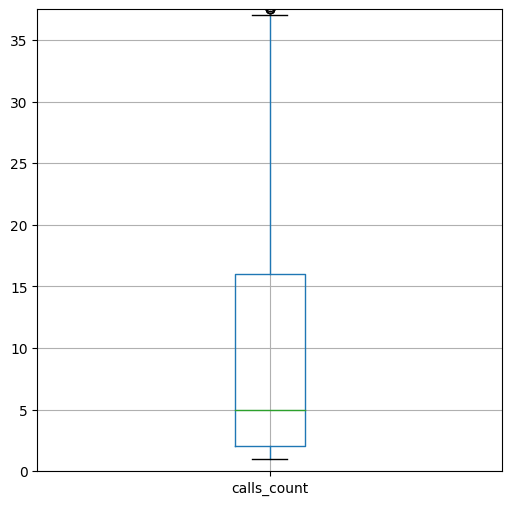

In [55]:
cnt_missed_call.boxplot(column='calls_count', figsize=(6,6))
plt.ylim(0, 37.5)

In [56]:
cnt_missed_call_cor = cnt_missed_call.query('calls_count <= calls_count.quantile(0.95)')
cnt_missed_call_cor['calls_count'].describe()

count    11711.000000
mean        10.809209
std         14.855648
min          1.000000
25%          2.000000
50%          4.000000
75%         13.000000
max         74.000000
Name: calls_count, dtype: float64

/opt/anaconda3/envs/practicum/lib/python3.9/site-packages/seaborn/distributions.py:2557: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


Text(0.5, 1.0, 'Number of Missed Calls per Day')

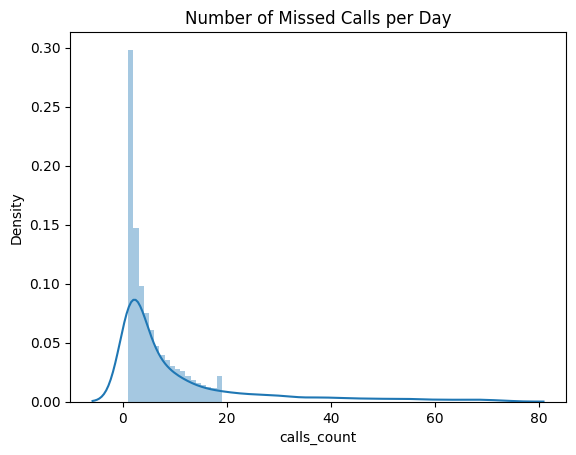

In [57]:
sns.distplot(cnt_missed_call_cor['calls_count'], norm_hist=True, bins = range(20))
plt.title('Number of Missed Calls per Day')

In [58]:
np.percentile(cnt_missed_call_cor['calls_count'], [55, 60])

array([5., 7.])

**Based on cleaned data**

Most values ​​are between 0 and 5.

The average number of missed calls per day for operators is 10.81.

25% of operators miss up to 2 calls per day.

50% of operators missed fewer than 4 calls.

75% of operators missed fewer than 13 calls.

The maximum number of missed calls is 74.

*We'll set a threshold of **6 calls**, after which the number of missed calls will be considered high. Accordingly, operators who miss 5 calls per day will be considered ineffective.*

**A feature that identifies operators who miss more than 5 calls per day**

In [59]:
def cnt_missed_call(calls_count):
    if calls_count > 6:
        return 'non-efficient'
    else:
        return 'accept'
 
cnt_missed_call_cor['check'] = cnt_missed_call_cor['calls_count'].apply(cnt_missed_call)

In [60]:
cnt_missed_call_cor.head()

,operator_id,date,calls_count,check
0,879896.0,2019-08-02,8.0,non-efficient
1,879896.0,2019-08-03,7.0,non-efficient
2,879896.0,2019-08-04,1.0,accept
3,879896.0,2019-08-05,1.0,accept
4,879896.0,2019-08-06,4.0,accept


### 2.4. Number of Outgoing Calls. Criteria for Identifying Ineffective Agents<a class="anchor" id="2-4-bullet"></a>

In [61]:
outgoing_calls = telecom_dataset[telecom_dataset['direction'] == "out"].reset_index()
outgoing_calls.head(5)

,index,user_id,date,direction,internal,operator_id,is_missed_call,calls_count,call_duration,total_call_duration,waiting_time,avg_wait_time_per_call
0,1,166377,2019-08-05,out,1,880022.0,1,3,0,5,5,1.666667
1,2,166377,2019-08-05,out,1,880020.0,1,1,0,1,1,1.000000
2,3,166377,2019-08-05,out,1,880020.0,0,1,10,18,8,8.000000
3,4,166377,2019-08-05,out,0,880022.0,1,3,0,25,25,8.333333
4,5,166377,2019-08-05,out,0,880020.0,0,2,3,29,26,13.000000


In [62]:
cnt_outgoing_calls_per_day = outgoing_calls.groupby(['operator_id', 'date'])['calls_count'].mean().reset_index()
cnt_outgoing_calls_per_day

,operator_id,date,calls_count
0,879896.0,2019-08-02,4.333333
1,879896.0,2019-08-03,5.000000
2,879896.0,2019-08-04,1.000000
3,879896.0,2019-08-05,9.333333
4,879896.0,2019-08-06,16.200000
...,...,...,...
15108,972412.0,2019-11-27,13.000000
15109,972412.0,2019-11-28,17.000000
15110,972460.0,2019-11-27,2.750000
15111,972460.0,2019-11-28,19.000000


In [63]:
cnt_outgoing_calls_per_day['calls_count'].describe()

count    15113.000000
mean        19.496696
std         62.646601
min          1.000000
25%          2.000000
50%          5.000000
75%         16.000000
max       2511.000000
Name: calls_count, dtype: float64

<AxesSubplot:>

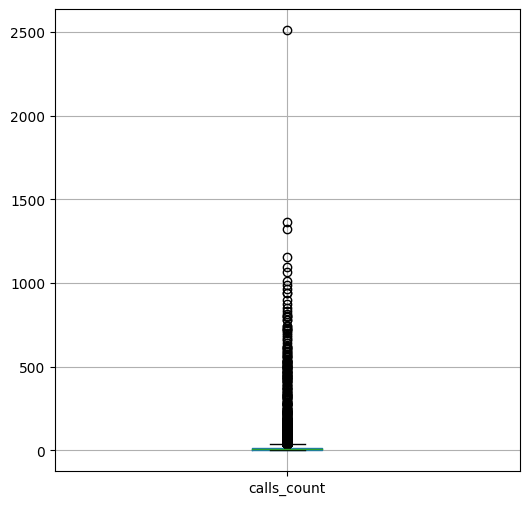

In [64]:
cnt_outgoing_calls_per_day.boxplot(column='calls_count', figsize=(6,6))

The sample mean is 19 calls.

The standard deviation of 62.7 indicates anomalies and outliers.

25% of agents make no more than 2 calls per day.

25% of agents make no more than 5 calls per day.

25% of agents make no more than 16 calls per day.

The maximum outlier is 2 511 calls. Let's assume an agent has a 12-hour workday. To make this many calls, they would have to make a call every 3 seconds without a break. This number is abnormal.

Let's zoom in on the boxplot to see where the normal values ​​end and the outliers begin.

(0.0, 37.5)

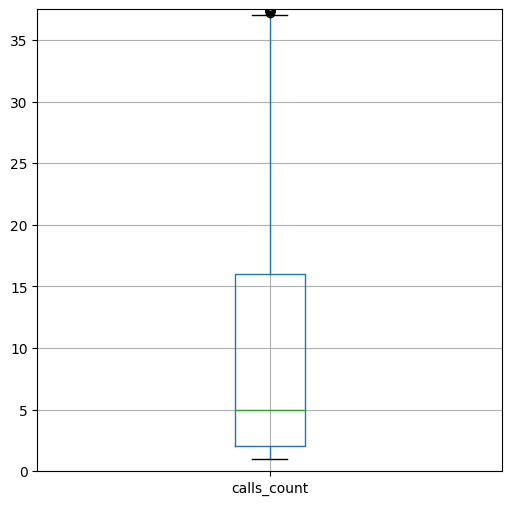

In [65]:
cnt_outgoing_calls_per_day.boxplot(column='calls_count', figsize=(6,6))
plt.ylim(0,37.5)

In [66]:
cnt_outgoing_calls_per_day_cor = cnt_outgoing_calls_per_day.query('calls_count <= calls_count.quantile(0.95)')
cnt_outgoing_calls_per_day_cor['calls_count'].describe()

count    14362.000000
mean        10.624050
std         13.949063
min          1.000000
25%          2.000000
50%          4.500000
75%         13.333333
max         69.500000
Name: calls_count, dtype: float64

/opt/anaconda3/envs/practicum/lib/python3.9/site-packages/seaborn/distributions.py:2557: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


Text(0.5, 1.0, 'Number of Outgoing Calls per Day')

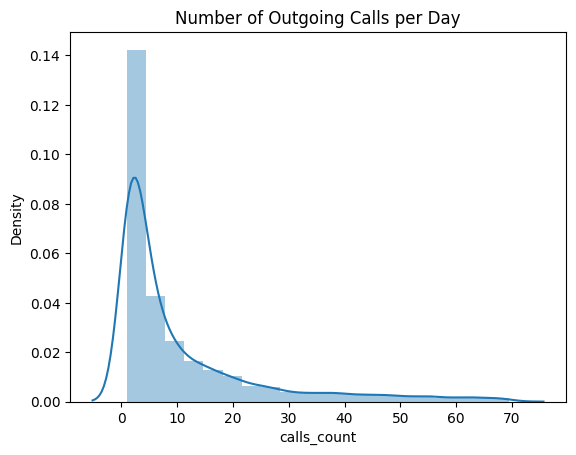

In [67]:
sns.distplot(cnt_outgoing_calls_per_day_cor['calls_count'], bins=20)
plt.title('Number of Outgoing Calls per Day')

In [68]:
np.percentile(cnt_outgoing_calls_per_day_cor['calls_count'], [55, 60, 62])

array([5.5       , 6.75      , 7.33333333])

According to the cleaned data:

Most values ​​are between 1 and 5.

The average value for the sample is 10.62 outgoing calls per day.

25% of agents make no more than 2 calls per day.

50% of agents make no more than 4.5 calls per day.

75% of agents make no more than 13.3 calls per day.

The maximum number of calls per day is 69.5.

*We'll set a threshold of 7 calls, below which the number of outgoing calls will be considered insufficient. Accordingly, agents making fewer than 6 calls per day will be considered ineffective.*

**A function that identifies operators whose number of outgoing calls is less than 6**

In [69]:
pd.options.mode.chained_assignment = None

In [70]:
def cnt_outgoing_calls(calls_count):
    if calls_count < 7:
        return 'non-efficient'
    else:
        return 'accept'
 
cnt_outgoing_calls_per_day_cor['check'] = cnt_outgoing_calls_per_day_cor['calls_count'].apply(cnt_outgoing_calls)

In [71]:
cnt_outgoing_calls_per_day_cor.head()

,operator_id,date,calls_count,check
0,879896.0,2019-08-02,4.333333,non-efficient
1,879896.0,2019-08-03,5.000000,non-efficient
2,879896.0,2019-08-04,1.000000,non-efficient
3,879896.0,2019-08-05,9.333333,accept
4,879896.0,2019-08-06,16.200000,accept


### Step 3. Hypothesis Testing<a class="anchor" id="3-bullet"></a>

In [72]:
telecom = telecom_dataset.merge(telecom_clients, on='user_id', how='inner')
telecom.head()

,user_id,date,direction,internal,operator_id,is_missed_call,calls_count,call_duration,total_call_duration,waiting_time,avg_wait_time_per_call,tariff_plan,date_start
0,166377,2019-08-05,out,1,880022.0,1,3,0,5,5,1.666667,B,2019-08-01
1,166377,2019-08-05,out,1,880020.0,1,1,0,1,1,1.000000,B,2019-08-01
2,166377,2019-08-05,out,1,880020.0,0,1,10,18,8,8.000000,B,2019-08-01
3,166377,2019-08-05,out,0,880022.0,1,3,0,25,25,8.333333,B,2019-08-01
4,166377,2019-08-05,out,0,880020.0,0,2,3,29,26,13.000000,B,2019-08-01


In [73]:
telecom.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 45670 entries, 0 to 45669
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   user_id                 45670 non-null  int64         
 1   date                    45670 non-null  datetime64[ns]
 2   direction               45670 non-null  object        
 3   internal                45670 non-null  int64         
 4   operator_id             45670 non-null  float64       
 5   is_missed_call          45670 non-null  int64         
 6   calls_count             45670 non-null  int64         
 7   call_duration           45670 non-null  int64         
 8   total_call_duration     45670 non-null  int64         
 9   waiting_time            45670 non-null  int64         
 10  avg_wait_time_per_call  45670 non-null  float64       
 11  tariff_plan             45670 non-null  object        
 12  date_start              45670 non-null  dateti

In [74]:
telecom.groupby('tariff_plan')['user_id'].nunique()

tariff_plan
A     32
B    101
C    157
Name: user_id, dtype: int64

The dataset contains 32 unique users using plan A (11.03%).

101 unique users use plan B (34.83%).

157 unique users use plan C (54.14%).

### 3.1. Testing the Hypothesis About Differences in Incoming Call Wait Times Depending on Tariff Plan<a class="anchor" id="3-1-bullet"></a>

In [75]:
telecom_avg_time = telecom.query('avg_wait_time_per_call <= 42')
telecom_avg_time.head()

,user_id,date,direction,internal,operator_id,is_missed_call,calls_count,call_duration,total_call_duration,waiting_time,avg_wait_time_per_call,tariff_plan,date_start
0,166377,2019-08-05,out,1,880022.0,1,3,0,5,5,1.666667,B,2019-08-01
1,166377,2019-08-05,out,1,880020.0,1,1,0,1,1,1.000000,B,2019-08-01
2,166377,2019-08-05,out,1,880020.0,0,1,10,18,8,8.000000,B,2019-08-01
3,166377,2019-08-05,out,0,880022.0,1,3,0,25,25,8.333333,B,2019-08-01
4,166377,2019-08-05,out,0,880020.0,0,2,3,29,26,13.000000,B,2019-08-01


In [76]:
sample_A = telecom_avg_time[telecom_avg_time['tariff_plan'] == 'A']['avg_wait_time_per_call'].reset_index()
sample_A['avg_wait_time_per_call'].describe()

count    13078.000000
mean        16.158125
std          9.269104
min          0.000000
25%          8.717532
50%         16.000000
75%         22.000000
max         42.000000
Name: avg_wait_time_per_call, dtype: float64

In [77]:
sample_B = telecom_avg_time[telecom_avg_time['tariff_plan'] == 'B']['avg_wait_time_per_call'].reset_index()
sample_B['avg_wait_time_per_call'].describe()

count    15239.000000
mean        15.591886
std          9.485725
min          0.000000
25%          9.000000
50%         14.000000
75%         20.800000
max         42.000000
Name: avg_wait_time_per_call, dtype: float64

In [78]:
sample_С = telecom_avg_time[telecom_avg_time['tariff_plan'] == 'C']['avg_wait_time_per_call'].reset_index()
sample_С['avg_wait_time_per_call'].describe()

count    15934.000000
mean        14.411680
std          9.025517
min          0.000000
25%          7.500000
50%         13.545455
75%         19.500000
max         42.000000
Name: avg_wait_time_per_call, dtype: float64


Let's look at the graph that characterizes the shape of the distribution

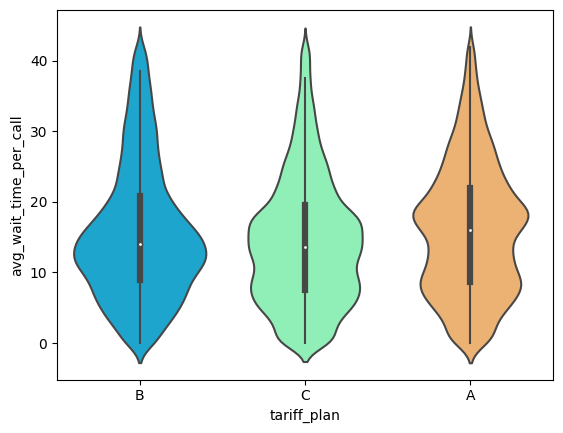

In [79]:
sns.violinplot(x="tariff_plan", y="avg_wait_time_per_call", data=telecom_avg_time, palette='rainbow');

The median in tariffs B (14 seconds) and C (13.5 seconds) is approximately the same, while in tariff A it is higher (16 seconds).

The first quartile in tariff C (7.5 seconds) is lower than in tariffs A (8.7 seconds) and B (9 seconds).

The third quartile in tariff C is lower (19.5 seconds) than in tariffs A (22 seconds) and B (20 seconds).

Target B has one peak. Most of the data is collected around 13 seconds.

Traffic C has two peaks. Most of the data is collected around 8 and 16 seconds.

Traffic A has two peaks. Most of the data is collected around 9 and 18 seconds.

**According to current data, operators on tariff C respond the fastest, then B. Operators on tariff A respond the slowest.**

We will test the hypothesis about the difference between the tariffs using statistical significance.

***Null Hypothesis*** - There is no statistically significant difference between the call waiting times for incoming calls.

***Alternative Hypothesis*** - There is a statistically significant difference between the call waiting times for incoming calls.

**Nonparametric Wilcoxon-Mann-Whitney Test**

***The test is robust to outliers and anomalies***

The nonparametric method operates on ranks—the numbers of values ​​in an ordered series—without taking the values ​​themselves into account. Therefore, we resort to it when working with the values ​​themselves is impossible due to outliers that significantly bias the parametric results.
Outliers and anomalies were discovered in the data during exploratory data analysis.

In [80]:
sample_A = telecom[telecom['tariff_plan'] == 'A']['avg_wait_time_per_call']
sample_B = telecom[telecom['tariff_plan'] == 'B']['avg_wait_time_per_call']
sample_C = telecom[telecom['tariff_plan'] == 'C']['avg_wait_time_per_call']

***Function for performing the Wilcoxon-Mann-Whitney test***

In [81]:
def mannwhitneyu_test(a, b, c):
    alpha = .05
    results_AB_mannwhitneyu = st.mannwhitneyu(sample_A, sample_B)
    results_BC_mannwhitneyu = st.mannwhitneyu(sample_B, sample_C)
    results_AC_mannwhitneyu = st.mannwhitneyu(sample_A, sample_C)
    print('p-value for comparison of groups A and B: ', results_AB_mannwhitneyu.pvalue)
    print('p-value for comparison of groups B and C: ', results_BC_mannwhitneyu.pvalue)
    print('p-value for comparison of groups A and C: ', results_AC_mannwhitneyu.pvalue)
    if (results_AB_mannwhitneyu.pvalue < alpha):
        print("We reject the null hypothesis for the comparison of tariffs A and B: the difference is statistically significant")
    else:
        print("The null hypothesis for the comparison of tariffs A and B could not be rejected, and a conclusion about the difference cannot be drawn.")

    if (results_BC_mannwhitneyu.pvalue < alpha):
        print("We reject the null hypothesis for the comparison of tariffs B and C: the difference is statistically significant")
    else:
        print("The null hypothesis for the comparison of tariffs B and C could not be rejected, and no conclusion about the difference can be drawn.")

    if (results_AC_mannwhitneyu.pvalue < alpha):
        print("We reject the null hypothesis for the comparison of tariffs A and C: the difference is statistically significant")
    else:
        print("The null hypothesis for the comparison of tariffs A and C could not be rejected, and no conclusion about the difference can be drawn.")

In [82]:
mannwhitneyu_test(sample_A, sample_B, sample_C)

p-value for comparison of groups A and B:  4.710418144830537e-07
p-value for comparison of groups B and C:  6.749450389503363e-31
p-value for comparison of groups A and C:  1.4457356430715888e-62
We reject the null hypothesis for the comparison of tariffs A and B: the difference is statistically significant
We reject the null hypothesis for the comparison of tariffs B and C: the difference is statistically significant
We reject the null hypothesis for the comparison of tariffs A and C: the difference is statistically significant


### 3.2. Testing the Hypothesis About Differences in the Number of Missed Incoming Calls Depending on Tariff Plan<a class="anchor" id="3-2-bullet"></a>

In [83]:
telecom_missed_call = telecom[telecom['is_missed_call'] == 1].reset_index()
telecom_missed_call.head()

,index,user_id,date,direction,internal,operator_id,is_missed_call,calls_count,call_duration,total_call_duration,waiting_time,avg_wait_time_per_call,tariff_plan,date_start
0,0,166377,2019-08-05,out,1,880022.0,1,3,0,5,5,1.666667,B,2019-08-01
1,1,166377,2019-08-05,out,1,880020.0,1,1,0,1,1,1.000000,B,2019-08-01
2,3,166377,2019-08-05,out,0,880022.0,1,3,0,25,25,8.333333,B,2019-08-01
3,5,166377,2019-08-05,out,0,880020.0,1,8,0,50,50,6.250000,B,2019-08-01
4,6,166377,2019-08-05,out,0,880020.0,1,8,0,50,50,6.250000,B,2019-08-01


In [84]:
telecom_missed_call = telecom_missed_call.groupby(['tariff_plan', 'date'])['calls_count'].sum().reset_index()
telecom_missed_call.head()

,tariff_plan,date,calls_count
0,A,2019-08-12,332
1,A,2019-08-13,370
2,A,2019-08-14,417
3,A,2019-08-15,382
4,A,2019-08-16,515


(0.0, 2600.0)

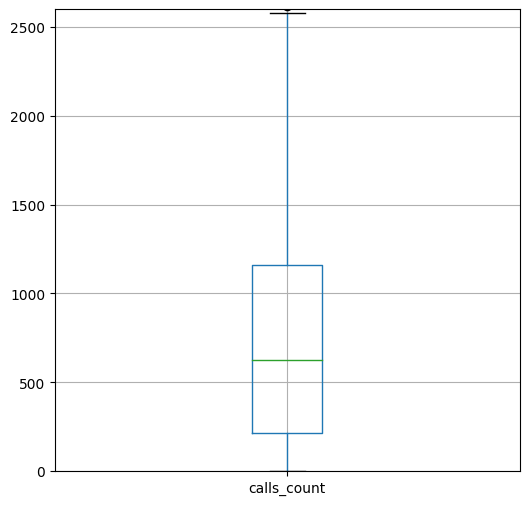

In [85]:
telecom_missed_call.boxplot(column='calls_count', figsize=(6,6))
plt.ylim(0,2600)

In [86]:
telecom_missed_call_cor = telecom_missed_call.query('calls_count <= 2600')

In [87]:
sample_A = telecom_missed_call_cor[telecom_missed_call_cor['tariff_plan'] == 'A'].reset_index()
sample_A['calls_count'].describe()

count      89.000000
mean     1180.820225
std       717.061674
min       132.000000
25%       595.000000
50%      1059.000000
75%      1729.000000
max      2576.000000
Name: calls_count, dtype: float64

In [88]:
sample_B = telecom_missed_call_cor[telecom_missed_call_cor['tariff_plan'] == 'B'].reset_index()
sample_B['calls_count'].describe()

count     118.000000
mean      403.525424
std       370.013992
min         1.000000
25%        98.250000
50%       302.500000
75%       616.750000
max      1213.000000
Name: calls_count, dtype: float64

In [89]:
sample_C = telecom_missed_call_cor[telecom_missed_call_cor['tariff_plan'] == 'C'].reset_index()
sample_C['calls_count'].describe()

count     104.000000
mean      669.903846
std       570.339679
min         1.000000
25%       161.000000
50%       608.500000
75%       946.750000
max      2365.000000
Name: calls_count, dtype: float64

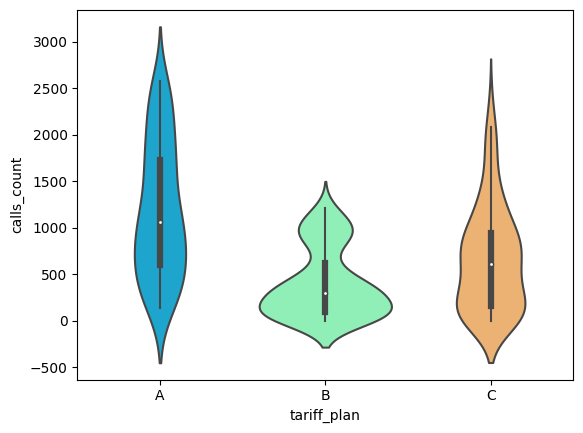

In [90]:
sns.violinplot(x="tariff_plan", y="calls_count", data=telecom_missed_call_cor, palette='rainbow');

The median for Plan A (1 059 calls) is significantly higher than for Plan C (608.5 calls). The median for Plan C is higher than for Plan B (302.5 calls).

The first quartile for Plan A (595 calls) is significantly higher than for Plan C (161 calls). The first quartile for Plan C is higher than for Plan B (98.3 calls).

The third quartile for Plan A (1 729 calls) is significantly higher than for Plan C (946.75 calls). The third quartile for Plan C is higher than for Plan B (616.8 calls).

Tariff B has one significant peak. Most of the data is collected around 100 calls. There is a further minor peak around 1 000 calls. The maximum value is 1 213.

Traffic in Plan C has two peaks. Most of the data was collected between 100 and 800 calls. The maximum number was 2 365.

Traffic type A has no significant peaks.
Maximum number was 2 576.

**According to current data, operators on plan B have the fewest missed incoming calls, followed by those on plan C. Operators on plan A have the highest number of unanswered calls.**

We will test the hypothesis about the difference between the plans using statistical significance.

***Null Hypothesis*** - There is no statistically significant difference between tariffs in terms of the number of missed incoming calls.

***Alternative Hypothesis*** - There is a statistically significant difference between different tariffs in terms of the number of missed incoming calls.

**Nonparametric Wilcoxon-Mann-Whitney test**

In [91]:
sample_A = telecom_missed_call[telecom_missed_call['tariff_plan'] == 'A']['calls_count']
sample_B = telecom_missed_call[telecom_missed_call['tariff_plan'] == 'B']['calls_count']
sample_C = telecom_missed_call[telecom_missed_call['tariff_plan'] == 'C']['calls_count']

In [92]:
mannwhitneyu_test(sample_A, sample_B, sample_C)

p-value for comparison of groups A and B:  2.8774353455197273e-21
p-value for comparison of groups B and C:  0.0008070075145397256
p-value for comparison of groups A and C:  2.373516643848276e-10
We reject the null hypothesis for the comparison of tariffs A and B: the difference is statistically significant
We reject the null hypothesis for the comparison of tariffs B and C: the difference is statistically significant
We reject the null hypothesis for the comparison of tariffs A and C: the difference is statistically significant


### 3.3. Testing the Hypothesis About Differences in the Number of Outgoing Calls Depending on Tariff Plan<a class="anchor" id="3-3-bullet"></a>

In [93]:
telecom_outgoing_calls = telecom[telecom['direction'] == "out"].reset_index()
telecom_outgoing_calls.head(5)

,index,user_id,date,direction,internal,operator_id,is_missed_call,calls_count,call_duration,total_call_duration,waiting_time,avg_wait_time_per_call,tariff_plan,date_start
0,0,166377,2019-08-05,out,1,880022.0,1,3,0,5,5,1.666667,B,2019-08-01
1,1,166377,2019-08-05,out,1,880020.0,1,1,0,1,1,1.000000,B,2019-08-01
2,2,166377,2019-08-05,out,1,880020.0,0,1,10,18,8,8.000000,B,2019-08-01
3,3,166377,2019-08-05,out,0,880022.0,1,3,0,25,25,8.333333,B,2019-08-01
4,4,166377,2019-08-05,out,0,880020.0,0,2,3,29,26,13.000000,B,2019-08-01


In [94]:
telecom_outgoing_calls = telecom_outgoing_calls.groupby(['tariff_plan', 'date'])['calls_count'].sum().reset_index()
telecom_missed_call.head()

,tariff_plan,date,calls_count
0,A,2019-08-12,332
1,A,2019-08-13,370
2,A,2019-08-14,417
3,A,2019-08-15,382
4,A,2019-08-16,515


(0.0, 6100.0)

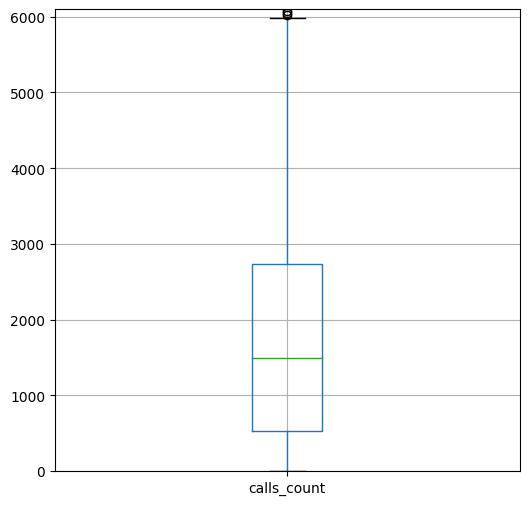

In [95]:
telecom_outgoing_calls.boxplot(column='calls_count', figsize=(6,6))
plt.ylim(0,6100)

In [96]:
telecom_outgoing_calls_cor = telecom_outgoing_calls.query('calls_count <= 6000')

In [97]:
sample_A = telecom_outgoing_calls_cor[telecom_outgoing_calls_cor['tariff_plan'] == 'A']['calls_count'].reset_index()
sample_A['calls_count'].describe()

count      91.000000
mean     2783.153846
std      1611.440059
min       268.000000
25%      1477.500000
50%      2506.000000
75%      3906.500000
max      5980.000000
Name: calls_count, dtype: float64

In [98]:
sample_B = telecom_outgoing_calls_cor[telecom_outgoing_calls_cor['tariff_plan'] == 'B']['calls_count'].reset_index()
sample_B['calls_count'].describe()

count     118.000000
mean     1027.466102
std       919.611045
min         2.000000
25%       216.750000
50%       843.000000
75%      1607.000000
max      3043.000000
Name: calls_count, dtype: float64

In [99]:
sample_C = telecom_outgoing_calls_cor[telecom_outgoing_calls_cor['tariff_plan'] == 'C']['calls_count'].reset_index()
sample_C['calls_count'].describe()

count     107.000000
mean     1450.719626
std      1198.183954
min         1.000000
25%       334.500000
50%      1404.000000
75%      2225.500000
max      4923.000000
Name: calls_count, dtype: float64

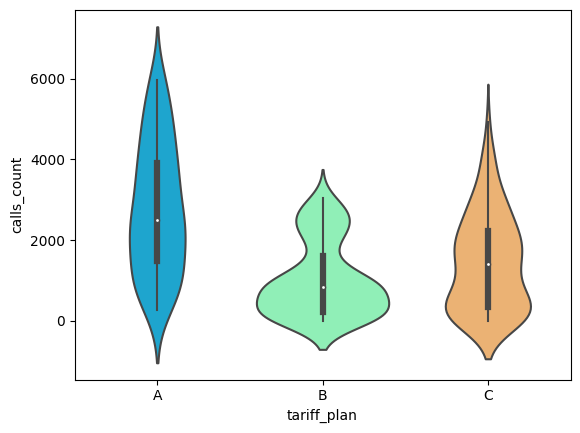

In [100]:
sns.violinplot(x="tariff_plan", y="calls_count", data=telecom_outgoing_calls_cor, palette='rainbow');

The median for Plan A (2 506 calls) is significantly higher than for Plan C (1 404 calls). The median for Plan C is higher than for Plan B (843 calls).

The first quartile for Plan A (1 477.5 calls) is significantly higher than for Plan C (334.5 calls). The first quartile for Plan C is higher than for Plan B (216.75 calls).

The third quartile for Plan A (3,906 calls) is significantly higher than for Plan C (2 225.5 calls). The third quartile for Plan C is higher than for Plan B (1 607 calls).

Tariff B has one significant peak. Most of the data is collected around 425 calls. There is a minor peak at 2,550 calls. The maximum value is 3 043.

Traffic in Plan C has two peaks. Most of the data was collected between 300 and 2000 calls. The maximum number was 4 329.

Traffic type A has no significant peaks.
Maximum number was 5 980.

**According to current data, operators on plan A make the most outgoing calls, followed by those on plan C. Operators on plan B make the fewest outgoing calls.**

We will test the hypothesis about the difference between the plans using statistical significance.

***Null Hypothesis*** - There is no statistically significant difference between the rates for the number of outgoing calls.

***Alternative Hypothesis*** - There is a statistically significant difference between the different rates for outgoing calls.

**Nonparametric Wilcoxon-Mann-Whitney test**


In [101]:
sample_A = telecom_outgoing_calls[telecom_outgoing_calls['tariff_plan'] == 'A']['calls_count']
sample_B = telecom_outgoing_calls[telecom_outgoing_calls['tariff_plan'] == 'B']['calls_count']
sample_C = telecom_outgoing_calls[telecom_outgoing_calls['tariff_plan'] == 'C']['calls_count']

In [102]:
mannwhitneyu_test(sample_A, sample_B, sample_C)

p-value for comparison of groups A and B:  2.85353971376933e-20
p-value for comparison of groups B and C:  0.021947064278938735
p-value for comparison of groups A and C:  1.3151819340421992e-12
We reject the null hypothesis for the comparison of tariffs A and B: the difference is statistically significant
We reject the null hypothesis for the comparison of tariffs B and C: the difference is statistically significant
We reject the null hypothesis for the comparison of tariffs A and C: the difference is statistically significant


### Step 4. Conclusions and Recommendations<a class="anchor" id="4-bullet"></a>


    
**1. Number of operators at clients:**

* 50% of clients have no more than 2 operators;
* 75% of clients have no more than 4 operators.

**2. Can operators handle both outgoing and incoming calls?**

* 49.82% of operators handle both outgoing and incoming calls.
* 50.18% of operators handle only one group of calls.

**3. Criterion for identifying ineffective operators: wait time for an incoming external call**

A threshold of **15 seconds** is defined, after which the wait time is considered high. Accordingly, operators who answer an incoming external call for more than 15 seconds are considered ineffective.

**4. Criterion for identifying ineffective operators: number of missed calls**

A threshold of **6 calls** is defined, after which the number of missed calls is considered high. Accordingly, agents who miss more than 5 calls per day will be considered ineffective.

**5. Criterion for identifying ineffective agents - number of outgoing calls**

A threshold of **7 calls** has been established, below which the number of outgoing calls will be considered insufficient. Accordingly, agents who make fewer than 6 calls per day will be considered ineffective.

**6. Hypothesis Testing**

**6.1. Testing the Hypothesis on the Difference in Incoming Call Wait Time Depending on the Tariff Plan**

We reject the null hypothesis for the comparison of tariffs A and B: the difference is statistically significant.
We reject the null hypothesis for the comparison of tariffs B and C: the difference is statistically significant.
We reject the null hypothesis for the comparison of tariffs A and C: the difference is statistically significant.
    
*According to current data, operators on plan C answer the fastest, then B. Operators on plan A answer the slowest*

**6.2. Testing the hypothesis about the difference in the number of missed incoming calls depending on the plan.**

We reject the null hypothesis for the comparison of plans A and B: the difference is statistically significant.
We reject the null hypothesis for the comparison of plans B and C: the difference is statistically significant.
We reject the null hypothesis for the comparison of plans A and C: the difference is statistically significant.

*According to current data, operators on plan B miss the fewest incoming calls, then C. Operators on plan A have the highest number of unanswered calls*

**6.3. Testing the hypothesis about the difference in the number of outgoing calls depending on the tariff plan.**

We reject the null hypothesis for the comparison of tariffs A and B: the difference is statistically significant.
We reject the null hypothesis for the comparison of tariffs B and C: the difference is statistically significant.
We reject the null hypothesis for the comparison of tariffs A and C: the difference is statistically significant.

*According to current data, operators on tariff A make the most outgoing calls, followed by those on tariff C. Operators on tariff B make the fewest outgoing calls.*

**General conclusion for operators**

* Operators on tariff A focus on outgoing calls. They have the best performance in this group by this criterion. For incoming calls, operators on tariff A have the worst performance by both criteria: wait time and number of missed calls.

* Operators on tariff B focus on incoming calls. The best indicator for the "number of missed calls" criterion and second place for the "answer wait time" criterion. However, the worst result for the "number of outgoing calls" criterion.
    
* **C** tariff operators focus on both incoming and outgoing calls. They ranked second for "number of outgoing calls" and "number of missed calls." They took first place for "wait time."